# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [3]:
sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')

Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [4]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output = np.array(output, dtype=float)
    n = len(input_feature)

    if n == 0:
        raise ValueError('input_feature та output не можуть бути порожніми')
    if n != len(output):
        raise ValueError('input_feature та output повинні мати однакову довжину')

    x_mean = input_feature.mean()
    y_mean = output.mean()

    numerator = np.sum(input_feature * output) - n * x_mean * y_mean
    denominator = np.sum(input_feature ** 2) - n * x_mean ** 2

    if denominator == 0:
        raise ValueError('Неможливо обчислити slope: усі значення ознаки однакові')

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return intercept, slope

### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [5]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [6]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [7]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""
    input_feature = np.array(input_feature, dtype=float)
    predictions = intercept + slope * input_feature
    return predictions

In [8]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    """Повертає RSS (скаляр)."""
    output = np.array(output, dtype=float)
    predictions = get_regression_predictions(input_feature, intercept, slope)
    residuals = output - predictions
    rss = np.sum(residuals ** 2)
    return rss

### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [9]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [10]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [11]:
my_house_sqft = 2650
# Завдання 3в — обчисліть і виведіть передбачувану ціну
predicted_price = get_regression_predictions(my_house_sqft, sqft_intercept, sqft_slope)
print(f'Передбачувана ціна будинку площею {my_house_sqft} кв. футів: ${predicted_price:,.2f}')

Передбачувана ціна будинку площею 2650 кв. футів: $695,105.98


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [12]:
# Навчіть модель на ознаці bedrooms
bedrooms_intercept, bedrooms_slope = simple_linear_regression(
    train_data['bedrooms'], train_data['price']
)

print('Модель bedrooms:')
print(f'Вільний член: {bedrooms_intercept:.2f}')
print(f'Нахил: {bedrooms_slope:.4f}')

# Обчисліть тестову RSS для обох моделей
sqft_test_rss = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)

bedrooms_test_rss = get_residual_sum_of_squares(
    test_data['bedrooms'], test_data['price'],
    bedrooms_intercept, bedrooms_slope
)

print()
print('Порівняння RSS на тестовій вибірці:')
print(f'RSS для sqft_living: {sqft_test_rss:.2e}')
print(f'RSS для bedrooms:    {bedrooms_test_rss:.2e}')

better_feature = 'sqft_living' if sqft_test_rss < bedrooms_test_rss else 'bedrooms'
print(f'Краща ознака для прогнозу: {better_feature}')

Модель bedrooms:
Вільний член: 195271.72
Нахил: 101863.9402

Порівняння RSS на тестовій вибірці:
RSS для sqft_living: 1.20e+15
RSS для bedrooms:    2.15e+15
Краща ознака для прогнозу: sqft_living


**Відповідь:** Кращий прогноз дає ознака `sqft_living`, оскільки її RSS на тестовій вибірці менший, ніж RSS моделі на основі `bedrooms`. Це логічно, бо площа житла має більш прямий і кількісно точний зв'язок із ціною будинку, тоді як кількість спалень є грубішою ознакою і не враховує реальний розмір кімнат, якість будинку та інші характеристики.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [13]:
def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""
    if slope == 0:
        raise ValueError('Неможливо виконати зворотний прогноз: slope дорівнює 0')
    estimated_input = (output - intercept) / slope
    return estimated_input

Орієнтовна площа для будинку вартістю $800,000: 3,033.48 кв. футів


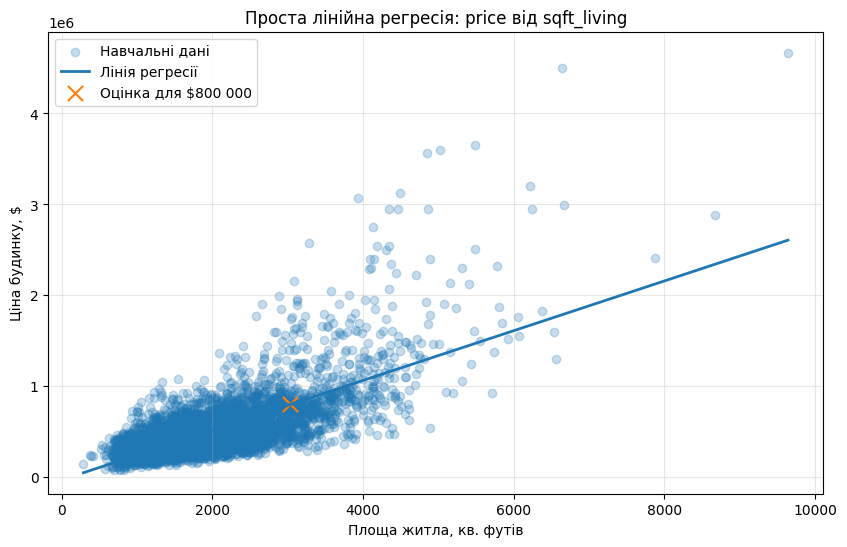

In [14]:
# Бонус — оцініть площу для будинку вартістю $800 000 та побудуйте графік
house_price = 800_000
estimated_sqft = inverse_regression_predictions(house_price, sqft_intercept, sqft_slope)
print(f'Орієнтовна площа для будинку вартістю ${house_price:,.0f}: {estimated_sqft:,.2f} кв. футів')

# Побудова графіка: навчальні дані + пряма регресії + знайдена точка
plt.figure(figsize=(10, 6))
plt.scatter(train_data['sqft_living'], train_data['price'], alpha=0.25, label='Навчальні дані')

x_values = np.linspace(train_data['sqft_living'].min(), train_data['sqft_living'].max(), 200)
y_values = get_regression_predictions(x_values, sqft_intercept, sqft_slope)
plt.plot(x_values, y_values, linewidth=2, label='Лінія регресії')

plt.scatter(estimated_sqft, house_price, s=120, marker='x', label='Оцінка для $800 000')
plt.xlabel('Площа житла, кв. футів')
plt.ylabel('Ціна будинку, $')
plt.title('Проста лінійна регресія: price від sqft_living')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Висновок

У лабораторній роботі реалізовано просту лінійну регресію аналітичним способом без використання `sklearn` для навчання моделі. Модель на основі `sqft_living` показала меншу RSS на тестовій вибірці, ніж модель на основі `bedrooms`, тому площа житла є кращою одиничною ознакою для прогнозування ціни будинку в цьому наборі даних. Також виконано зворотний прогноз: для ціни $800 000 оцінена необхідна площа становить приблизно 3033.48 кв. футів.